# Machine Learning Basics

This notebook demonstrates a basic **supervised machine learning** workflow for materials science using:

- [matminer](https://hackingmaterials.lbl.gov/matminer/) for dataset retrieval and featurization
- [scikit-learn](https://scikit-learn.org/) for model training and evaluation

Our goal is to predict the **experimental formation enthalpy** (in eV/atom) of inorganic compounds from compositional features.


## 1. Install Dependencies


In [1]:
!uv pip install matminer scikit-learn

Using Python 3.13.7 environment at: /Users/ct5868/personal/cbe423/.venv
Resolved 41 packages in 319ms                                        
⠙ Preparing packages... (0/4)                                                   
⠙ Preparing packages... (0/4)-------------------     0 B/498.52 KiB          
⠙ Preparing packages... (0/4)------------------- 14.91 KiB/498.52 KiB        
⠙ Preparing packages... (0/4)------------------- 30.91 KiB/498.52 KiB        
⠙ Preparing packages... (0/4)------------------- 46.91 KiB/498.52 KiB        
⠙ Preparing packages... (0/4)------------------- 62.91 KiB/498.52 KiB        
⠙ Preparing packages... (0/4)------------------- 76.78 KiB/498.52 KiB        
⠙ Preparing packages... (0/4)------------------- 92.78 KiB/498.52 KiB        
⠙ Preparing packages... (0/4)------------------- 108.78 KiB/498.52 KiB       
⠙ Preparing packages... (0/4)------------------- 108.78 KiB/498.52 KiB       
pytz                 ------------------------------ 108.78 KiB/498.52 KiB
⠙

## 2. Load the Dataset

We use the `expt_formation_enthalpy_kingsbury` dataset from matminer, which contains experimentally measured formation enthalpies for ~1500 inorganic compounds. For faster computation during this demo, we limit to the first 1000 entries.

The available datasets can be found on the [matminer website](https://hackingmaterials.lbl.gov/matminer/dataset_summary.html).

The dataset is loaded as a `pandas` dataframe object, which is a convenient format for tabular data. The syntax can be a bit clunky the first time you use it, but that is not our focus here today. Also, LLMs know most things about `pandas` if you need some support.


In [5]:
from matminer.datasets.dataset_retrieval import load_dataset

df = load_dataset("expt_formation_enthalpy_kingsbury")# pyright: ignore[reportOptionalMemberAccess]
df = df[0:1000]  # pyright: ignore[reportOptionalSubscript] # limit for quicker calculations
print(f"Dataset loaded: {df.shape[0]} entries, {df.shape[1]} columns")

Dataset loaded: 1000 entries, 6 columns


Let's take a look at what this dataframe has inside of it.


In [6]:
df.head(10)

,formula,expt_form_e,uncertainty,phaseinfo,reference,likely_mpid
0,Ag2CO3,-0.873708,0.004318,cryst,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-4691
2,Ag2O,-0.107443,0.002073,cubic,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-353
3,Ag2O3,0.070270,NaN,cryst,Standard Thermodynamic Properties of Chemical ...,mp-546190
4,Ag2S,-0.109861,0.002764,monocl,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-610517
5,Ag2SO4,-1.061745,0.001925,orth,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-5625
6,Ag2Se,-0.150282,0.002764,orth,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-568936
7,Ag2Te,-0.124371,0.002073,orth,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-1592
8,Ag2WO4,-1.370305,0.033462,cryst,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-637188
9,AgBr,-0.521841,0.004146,cubic,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-23231
10,AgBrO3,-0.054723,NaN,tetrag,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",None


## 3. Featurize the Compositions

Machine learning models require numerical input. We convert each chemical formula into a `Composition` object and then generate some statistical properties of the elements for the features:

- **Statistics**: minimum, maximum, range, mean, standard deviation across constituent elements
- **Properties**: atomic number, atomic weight, periodic table column/row, covalent radius, electronegativity

This yields a fixed-length numerical feature vector for each compound. You can find a list of the supported elemental properties and their values [here](https://github.com/hackingmaterials/matminer/tree/dfc0f4c830fb9eb9c3366bdb26be2722fd09ac06/src/matminer/utils/data_files/magpie_elementdata) and the supported statical properties [here](https://hackingmaterials.lbl.gov/matminer/matminer.featurizers.utils.html#module-matminer.featurizers.utils.stats).


In [7]:
from pymatgen.core import Composition

# Convert formula strings to Composition objects
df["composition"] = df["formula"].apply(Composition)

In [10]:
f = df.iloc[0]['composition']

In [12]:
from matminer.featurizers.composition import ElementProperty

# Define which statistics and element properties to use
stats = ["minimum", "maximum", "range", "mean", "std_dev"]
features = [
    "Number",
    "AtomicWeight",
    "Column",
    "Row",
    "CovalentRadius",
    "Electronegativity",
]

# Build and apply the featurizer
featurizer = ElementProperty(data_source="magpie", features=features, stats=stats)
df = featurizer.featurize_dataframe(df, "composition")

print(f"Feature matrix shape: {df.filter(like='Magpie').shape}")

/Users/ct5868/personal/cbe423/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ElementProperty: 100%|██████████| 1000/1000 [00:17<00:00, 57.56it/s]


Feature matrix shape: (1000, 30)


Now let's take a look at our updated dataframe.


In [13]:
df.head(5)

,formula,expt_form_e,uncertainty,phaseinfo,reference,likely_mpid,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,...,MagpieData minimum CovalentRadius,MagpieData maximum CovalentRadius,MagpieData range CovalentRadius,MagpieData mean CovalentRadius,MagpieData std_dev CovalentRadius,MagpieData minimum Electronegativity,MagpieData maximum Electronegativity,MagpieData range Electronegativity,MagpieData mean Electronegativity,MagpieData std_dev Electronegativity
0,Ag2CO3,-0.873708,0.004318,cryst,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-4691,"(Ag, C, O)",6.0,47.0,41.0,...,66.0,145.0,79.0,94.000000,46.352405,1.93,3.44,1.51,2.788333,0.874531
2,Ag2O,-0.107443,0.002073,cubic,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-353,"(Ag, O)",8.0,47.0,39.0,...,66.0,145.0,79.0,118.666667,55.861436,1.93,3.44,1.51,2.433333,1.067731
3,Ag2O3,0.070270,NaN,cryst,Standard Thermodynamic Properties of Chemical ...,mp-546190,"(Ag, O)",8.0,47.0,39.0,...,66.0,145.0,79.0,97.600000,55.861436,1.93,3.44,1.51,2.836000,1.067731
4,Ag2S,-0.109861,0.002764,monocl,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-610517,"(Ag, S)",16.0,47.0,31.0,...,105.0,145.0,40.0,131.666667,28.284271,1.93,2.58,0.65,2.146667,0.459619
5,Ag2SO4,-1.061745,0.001925,orth,"O. Kubaschewski, C. Alcock, P. Spencer, Materi...",mp-5625,"(Ag, S, O)",8.0,47.0,39.0,...,66.0,145.0,79.0,94.142857,45.986023,1.93,3.44,1.51,2.885714,0.887295


## 4. Prepare Features and Target

We extract:

- `X`: the feature matrix (input)
- `y`: experimental formation enthalpy in eV/atom (target)


In [14]:
X = df.filter(like="Magpie").values
y = df["expt_form_e"].values

print(f"X shape: {X.shape}  →  {X.shape[0]} samples, {X.shape[1]} features")
print(f"y shape: {y.shape}")

X shape: (1000, 30)  →  1000 samples, 30 features
y shape: (1000,)


## 5. Explore the Target Variable

Before training, it's good practice to inspect the distribution of the target variable.


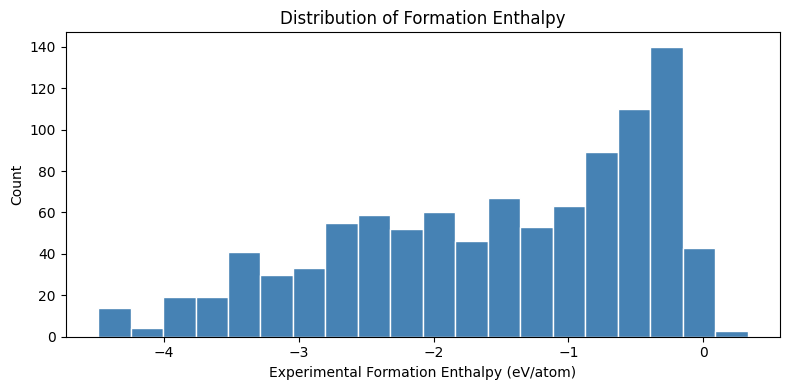

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(y, bins=20, color="steelblue", edgecolor="white")
plt.xlabel("Experimental Formation Enthalpy (eV/atom)")
plt.ylabel("Count")
plt.title("Distribution of Formation Enthalpy")
plt.tight_layout()
plt.show()

## 6. Train/Test Split

We split the data 80/20 into training and test sets. Setting `random_state=42` makes the split reproducible so we are all getting the same results.


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 800 samples
Test set:     200 samples


## 7. Train a Linear Regression Model

We start with a simple **linear regression** baseline — a straight-line mapping from features to formation enthalpy. Despite its simplicity, it provides a useful benchmark.


In [17]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


We can take a look at the trained model parameters, which should be 30 coefficients and 1 intercept.


In [18]:
regressor.coef_

array([-8.67129414e-02, -1.20551803e-01, -3.38388620e-02,  5.80887792e-01,
        1.40541934e-01,  3.52812618e-02,  4.12908212e-02,  6.00955943e-03,
       -1.81077937e-01, -3.75799431e-02,  5.40313336e-02, -5.30576777e-02,
       -1.07089011e-01, -3.19082824e-02,  1.85037052e-01,  2.91309316e-02,
        1.21321426e-01,  9.21904944e-02, -2.49076117e+00, -3.42235594e-01,
       -6.08377634e-03, -6.62627496e-04,  5.42114885e-03,  3.61394634e-02,
       -1.09273082e-02, -1.79490330e-01,  2.05505382e-01,  3.84995712e-01,
        1.18047739e-01, -2.63218769e+00])

In [19]:
regressor.intercept_

np.float64(1.940363913682246)

We can now use the trained model to make a prediction on the testing set to see how well it performs. Note that we have not fit the model to _all_ the data --- only to the training set!


In [20]:
y_pred_test = regressor.predict(X_test)

In [21]:
from sklearn.metrics import r2_score, mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print(f"MAE = {mae} eV/atom; r2 = {r2}")

MAE = 0.4194973506597515 eV/atom; r2 = 0.7436952833642807


Text(0.5, 1.0, 'Testing set parity plot')

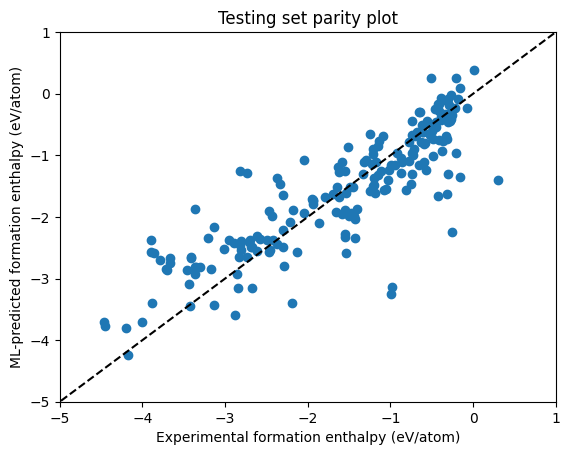

In [22]:
import numpy as np

parity = np.arange(-10, 5, 1)
plt.scatter(y_test, y_pred_test)
plt.plot(parity, parity, "k--")
plt.xlim([-5, 1])
plt.ylim([-5, 1])
plt.xlabel("Experimental formation enthalpy (eV/atom)")
plt.ylabel("ML-predicted formation enthalpy (eV/atom)")
plt.title("Testing set parity plot")

It looks like this very simple model, while not perfect by any means, is at least capturing something. Remember that the model has (in principle) never seen the testing set, so the respectable performance indicates that it is not overfitting.

Disclaimer: We did not thoroughly inspect the dataset, and it is possible that there could be similar structures in training and test, which would conflate the statistics.


## 10. Hyperparameter Selection with a Validation Set

Linear regression has no hyperparameters to tune — but richer models do. Here we switch to **Ridge Regression**, which adds an L2 regularisation penalty:

$$\mathcal{L} = \|y - X\beta\|^2 + \alpha \|\beta\|^2$$

The scalar $\alpha$ controls the strength of regularisation:

- **Small $\alpha$** → model is closer to ordinary least squares (can overfit)
- **Large $\alpha$** → coefficients are shrunk toward zero (can underfit)

Choosing $\alpha$ correctly matters. The right way to do this is:

1. **Split** data into train / **validation** / test (never touch the test set during tuning)
2. **Train** each candidate model on the training set
3. **Score** each on the validation set and pick the best $\alpha$
4. **Report** final performance on the held-out test set only once

> ⚠️ Using the test set to pick hyperparameters causes **data leakage** — your reported performance will be optimistically biased.


### 10a. Three-Way Split

We carve 20 % off for testing (as before), then split the remaining 80 % again into a training and held-out validaiton set. Of course, what you choose to do here is in practice up to you.


In [23]:
from sklearn.model_selection import train_test_split

# Step 1: hold out the test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Step 2: split the remainder into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.2,
    random_state=42,
)

print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_test.shape[0]} samples")

Train:      640 samples
Validation: 160 samples
Test:       200 samples


### 10b. Feature Scaling

Ridge regression is sensitive to the scale of the input features (unlike ordinary least squares). We fit a `StandardScaler` **on the training set only** and apply it to all three splits — fitting on validation or test data would leak information.


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit + transform on train
X_val_sc = scaler.transform(X_val)  # transform only on validation
X_test_sc = scaler.transform(X_test)  # transform only on testing

In [28]:
print("Features scaled. Train mean ≈ 0, std ≈ 1 (by construction).")
import numpy as np

print(f"  mean: {X_train_sc.mean(axis=0)[:3].round(6)} ...")
print(f"  std:  {X_train_sc.std(axis=0)[:3].round(6)} ...")

Features scaled. Train mean ≈ 0, std ≈ 1 (by construction).
  mean: [0. 0. 0.] ...
  std:  [1. 1. 1.] ...


### 10c. Sweep $\alpha$ and Record Validation Performance

We train a Ridge model for each candidate $\alpha$ value and record the validation R². This is the **hyperparameter search loop**.


In [29]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

alphas = np.logspace(-4, 0, 50)  # 50 values from 10^-4 to 10^0

train_maes, val_maes = [], []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_sc, y_train)
    mae_train = mean_absolute_error(y_train, model.predict(X_train_sc))
    mae_val = mean_absolute_error(y_val, model.predict(X_val_sc))
    train_maes.append(mae_train)
    val_maes.append(mae_val)

best_idx = int(np.argmin(val_maes))
best_alpha = alphas[best_idx]
print(
    f"Best α = {best_alpha:.4f}  →  Validation MAE = {val_maes[best_idx]:.4f} eV/atom"
)

Best α = 0.0043  →  Validation MAE = 0.4282 eV/atom


Text(0, 0.5, 'Validation MAE (eV/atom)')

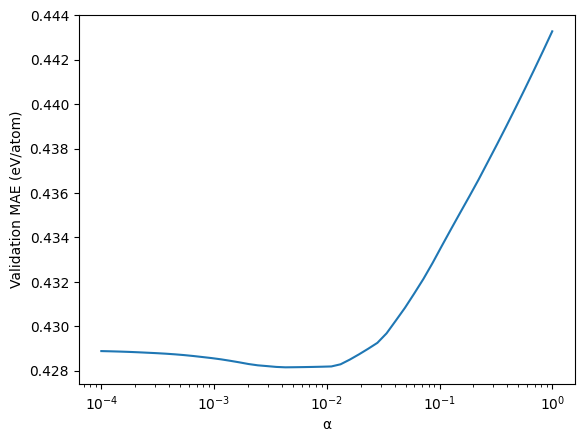

In [30]:
plt.semilogx(alphas, val_maes)
plt.xlabel("α")
plt.ylabel("Validation MAE (eV/atom)")

### 10d. Validation Curve

Plotting training and validation performance as a function of $\alpha$ reveals the classic **bias–variance trade-off**:

- At very **small $\alpha$**: training MAE is low but validation MAE may not be optimal (overfitting)
- At very **large $\alpha$**: both curves converge to a high MAE (underfitting)
- The **optimal $\alpha$** sits at the minimum MAE of the validation curve.


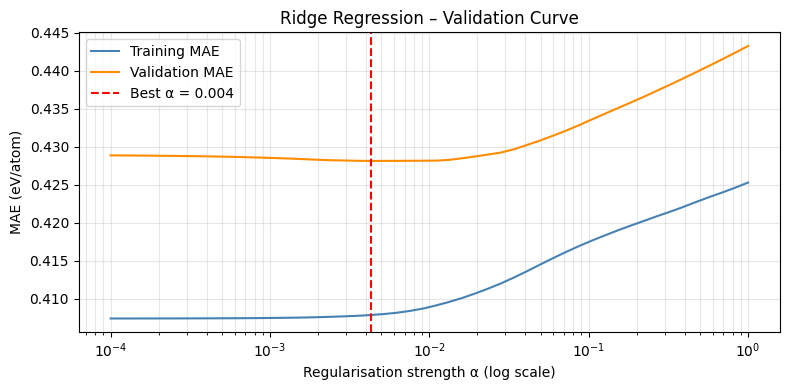

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogx(alphas, train_maes, label="Training MAE", color="steelblue")
ax.semilogx(alphas, val_maes, label="Validation MAE", color="darkorange")
ax.axvline(best_alpha, color="red", linestyle="--", label=f"Best α = {best_alpha:.3f}")

ax.set_xlabel("Regularisation strength α (log scale)")
ax.set_ylabel("MAE (eV/atom)")
ax.set_title("Ridge Regression – Validation Curve")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### 10e. Retrain on Train+Val and Evaluate on Test

Once we have chosen the best $\alpha$, we retrain on the **full train+validation set** to make the most of our data before computing the final test score. We can't make any changes to our model design though based on our testing set performance!

> This final test score is the number we report — we never touched it during tuning.


In [32]:
# Scale train+val together (refit scaler on larger set)
scaler_final = StandardScaler()
X_trainval_sc = scaler_final.fit_transform(X_trainval)
X_test_sc_final = scaler_final.transform(X_test)

In [33]:
# Retrain with best alpha from our validation MAE sweep
best_model = Ridge(alpha=best_alpha)
best_model.fit(X_trainval_sc, y_trainval)

y_pred_test = best_model.predict(X_test_sc_final)

In [34]:
from sklearn.metrics import mean_absolute_error

print("=== Final Test Performance ===")
print(f"  α   = {best_alpha:.4f}")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_test):.4f} (eV/atom)")
print(f"  R²  = {r2_score(y_test, y_pred_test):.4f}")

=== Final Test Performance ===
  α   = 0.0043
  MAE = 0.4207 (eV/atom)
  R²  = 0.7433


The results are basically the same as the linear regression model here, but you never know until you try.


### 10f. Parity Plot – Best Ridge Model


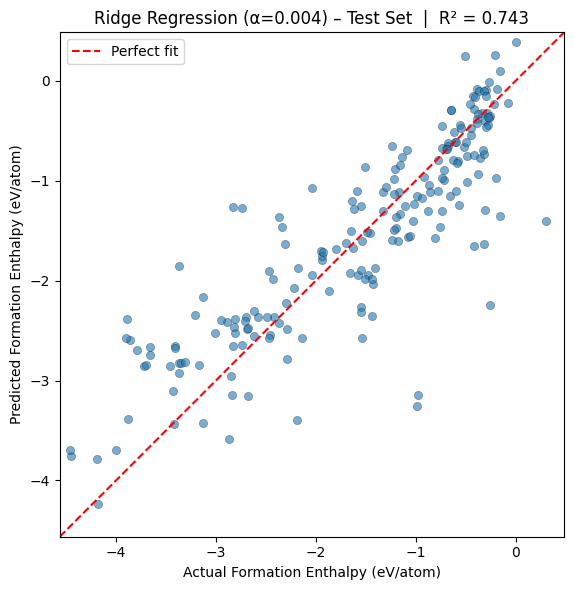

In [35]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, y_pred_test, alpha=0.6, edgecolors="k", linewidths=0.3, s=35)
lims = [
    min(y_test.min(), y_pred_test.min()) - 0.1,
    max(y_test.max(), y_pred_test.max()) + 0.1,
]
ax.plot(lims, lims, "r--", label="Perfect fit")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual Formation Enthalpy (eV/atom)")
ax.set_ylabel("Predicted Formation Enthalpy (eV/atom)")
ax.set_title(
    f"Ridge Regression (α={best_alpha:.3f}) – Test Set  |  R² = {r2_score(y_test, y_pred_test):.3f}"
)
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# Kernel Ridge Regression


We can do basically the same process for KRR. The performance will be greatly improved because we can introduce nonlinearity.

Note: There is a second hyperparameter `gamma`, but we will not change it from the default here for computational simplicity.


In [36]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import mean_absolute_error

alphas = np.logspace(-4, 0, 50)  # 50 values from 10^-4 to 10^0
train_maes, val_maes = [], []

for alpha in alphas:
    model = KernelRidge(alpha=alpha, kernel="polynomial")
    model.fit(X_train_sc, y_train)
    mae_train = mean_absolute_error(y_train, model.predict(X_train_sc))
    mae_val = mean_absolute_error(y_val, model.predict(X_val_sc))
    train_maes.append(mae_train)
    val_maes.append(mae_val)

best_idx = int(np.argmin(val_maes))
best_alpha = alphas[best_idx]
print(
    f"Best α = {best_alpha:.4f}  →  Validation MAE = {val_maes[best_idx]:.4f} eV/atom"
)

Best α = 0.0043  →  Validation MAE = 0.2431 eV/atom


## Summary

In this notebook we built an end-to-end ML workflow for predicting experimental formation enthalpy:

| Step       | What we did                                                 |
| ---------- | ----------------------------------------------------------- |
| Data       | Loaded `expt_formation_enthalpy_kingsbury` (1000 compounds) |
| Features   | 30 compositional descriptors                                |
| Baseline   | Linear regression (no hyperparameters, no scaling)          |
| Tuning     | Ridge regression with validation-set sweep over α           |
| Best model | Chosen at minimum validation MAE; retrained on train+val    |
| Evaluation | Reported once on a never-seen test set                      |
